# Location-tolerant segmentation metrics: `bb-spk-baseline-v3`

Standard IoU over-penalizes small position drift and doesn't reflect that "2 blobs
roughly right" should beat "1 blob right, 1 missed". This notebook implements 4 metric
families (the last one fully threshold-free) -- each **a single function, batched over a
whole split** -- and applies them to
`bb-spk-baseline-v3`'s saved predictions (train + eval/1-cube/2-cubes/3-cubes), then plots
predicted-mask-over-photo overlays sorted by whichever metric/split/best-or-worst you pick.

**Metrics**

1. **`iou_score`** -- the existing whole-grid soft IoU (`utils.metrics.soft_iou`), kept as
   the baseline everything else is compared against.
2. **`centroid_matching_score`** -- location-tolerant, threshold-swept blob detection.
   Binarize at 5 thresholds (chosen from notebook 85's finding that the useful range for
   this run's `mask_pred` sits well below the naive 0.05-0.95 sweep), connected-component
   each binarization, **optimally (Hungarian) match predicted blobs to GT blobs by nearest
   centroid** (`_match_by_distance`, below), and count a match as a hit only if the
   centroids are within a normalized distance tolerance. F1 over hits/extras/misses,
   averaged across the 5 thresholds.
3. **`panoptic_quality_iou`** / **`panoptic_quality_centroid`** -- Panoptic Quality
   (Kirillov et al., 2019: PQ = SQ x RQ, `SQ` = mean IoU of matched instances, `RQ` =
   instance-level F1) decomposed the same way, but matched on **component IoU swept over
   10 low thresholds** (0.05-0.5, not the usual 0.5 cutoff -- see chat) for the first
   variant, and on **normalized centroid distance** for the second (an OKS/FROC-style
   criterion: "roughly the right place" rather than "high overlap").

All four report one score per sample; `centroid_matching_score` and the PQ variants report
their own threshold sweep as a single **threshold-averaged** number, which is the answer to
"how do we deal with thresholding a `[0,1]` prediction" from the chat -- don't pick one
cutoff, average the metric across several.

**Matching, not `utils.metrics.match_objects`**: that shared helper (used by the training
loop's `localization()` metric) matches GREEDILY IN GT-LABEL ORDER -- when there are fewer
predictions than GT objects, whichever GT object is processed first takes the nearest
*remaining* prediction unconditionally, even if that prediction actually sits on top of a
*different*, later GT object. Verified with a synthetic 2-GT/1-pred case: a single
prediction placed exactly on GT object #2 was matched to GT object #1 instead (because #1
was processed first and had nothing else to claim), scoring F1=0.0 for a sample where the
model actually localized one object perfectly. `_match_by_distance` below instead runs
`scipy.optimize.linear_sum_assignment` on the full pairwise squared-distance matrix, the
same globally-optimal strategy `panoptic_quality_iou` already uses for IoU -- so the single
prediction is paired with whichever GT object it is actually closest to, independent of
processing order.


In [1]:

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (str(ROOT), str(ROOT / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import maximum_filter, label as ndi_label
import heapq

from viz.data import load_gt
from utils.metrics import soft_iou, _label, _centroids_batch

%matplotlib inline


## Config

In [2]:

# ---- edit me ----------------------------------------------------------------
RUN = "bb-spk-baseline-v3"
EPOCH = 1000                 # trained --max-duration 1000ep (see scripts/boombox_speaker_ablation.sh)
MASK_SHAPE = (32, 32)        # boombox's standardized output grid

EXPERIMENT = ROOT / "experiments" / "31_07_2026_gastronorm_exp1"
RUNS_DIR = ROOT / "runs"
SPLITS = ["train", "1-cube", "2-cubes", "3-cubes"]

# metric 1: connected-component binarization thresholds. mask_pred spans ~1e-19..1; notebook
# 85 found the correct-component-count optimum sits around 1e-3..5e-3, well below a naive
# linear sweep -- these 5 values span that low region plus the conventional 0.5 cutoff.
CENTROID_THRESHOLDS = [0.001, 0.005, 0.02, 0.1, 0.5]
CENTROID_TOL = 0.15          # "close enough": fraction of the box height/width, per axis

# metric 2: component-level IoU matching thresholds for panoptic_quality_iou -- swept LOW
# (0.05-0.5) rather than the usual single 0.5 cutoff, since precise overlap isn't the point.
PQ_IOU_THRESHOLDS = np.linspace(0.05, 0.5, 10)
# same idea, but for panoptic_quality_centroid's centroid-distance matching criterion.
PQ_CENTROID_THRESHOLDS = np.linspace(0.05, 0.3, 10)
# binarization thresholds used to FORM PQ's instances (separate from the matching
# thresholds above). A FIXED single value here was tried first (0.5, then 0.005) and
# rejected: 0.5 measurably starved PQ of matches (28.6% of 1-cube samples binarize to ZERO
# components, forcing FN before matching even runs -- see chat), and any single number,
# however carefully measured, is exactly the "arbitrary cutoff" problem this whole
# notebook exists to avoid -- see `centroid_matching_score`, which already sweeps instead
# of picking one. So PQ's instances are swept over the SAME 5 thresholds
# centroid_matching_score uses, and bin_thresh becomes a second swept axis alongside the
# matching threshold (iou_thresholds / dist_thresholds); the reported score is the BEST
# (sq, rq, pq) triple over the whole (bin_thresh, matching_thresh) grid, not an average
# (see the chat: an average punishes a sample for operating points it would never actually
# be scored at) -- consistent treatment, no run-specific magic number to hand-tune.
BIN_THRESHOLDS = CENTROID_THRESHOLDS

# default binarization threshold used only where a mask needs to be DRAWN as one concrete
# image (overlay_image, predicted_centroids) -- a plot needs one decision, unlike a score.
# The lowest of BIN_THRESHOLDS: better to show a faint real blob than an empty fill, and
# it's what "does the model have ANY signal here" should look like on a plot.
DISPLAY_THRESH = min(BIN_THRESHOLDS)

# metric 3: threshold-free peak+watershed instance decomposition (centroid_matching_score
# and panoptic_quality above still binarize, just at several thresholds instead of one --
# this is the actual no-binarization alternative, see soft_objects below). PEAK_MIN_VAL is
# NOT a segmentation cutoff -- it only rejects float noise from registering as a local
# maximum; it never decides a pixel's foreground/background status or a blob's extent.
PEAK_MIN_VAL = 1e-4
# -----------------------------------------------------------------------------


## Load

Ground truth loads once. Predictions come straight from `bb-spk-baseline-v3`'s saved eval
dumps (`OutputSaver` writes `mask_pred` + `info.sample_id`/`info.n_objects` per batch);
`mask_true` isn't saved, so it's joined back in via `sample_id` against `gt.row_of`, same as
notebook 85.

In [3]:

def load_run_split(run: str, split: str, epoch: int = EPOCH):
    """(sample_ids, mask_pred, n_objects) for one run/split/epoch, deduped by sample_id
    (last file wins -- mirrors viz.data.load_run's dedupe)."""
    d = RUNS_DIR / run / "outputs_history" / ("train" if split == "train" else f"eval/{split}")
    files = sorted(d.glob(f"ep{epoch:04d}-ba*.pt"))
    if not files:
        return (np.zeros(0, dtype=np.int64), np.zeros((0, *MASK_SHAPE), dtype=np.float32),
                np.zeros(0, dtype=np.int64))
    ids, masks, nobj = [], [], []
    for p in files:
        obj = torch.load(p, map_location="cpu", weights_only=False)
        ids.append(np.asarray(obj["info"]["sample_id"]).reshape(-1).astype(np.int64))
        masks.append(obj["mask_pred"].float().numpy())
        nobj.append(np.asarray(obj["info"]["n_objects"]).reshape(-1).astype(np.int64))
    ids, masks, nobj = np.concatenate(ids), np.concatenate(masks, axis=0), np.concatenate(nobj)
    keep = {int(s): i for i, s in enumerate(ids)}
    order = sorted(keep.values())
    return ids[order], masks[order], nobj[order]


gt = load_gt(EXPERIMENT, *MASK_SHAPE)
print(f"ground truth: {len(gt)} samples, grid {gt.masks.shape[1]}x{gt.masks.shape[2]}, "
      f"layout '{gt.layout.name}', backdrop '{gt.layout.backdrop}'")

split_data = {}   # split -> dict(sample_id, pred, gt, n_objects, photo_path)
for split in SPLITS:
    ids, preds, nobj = load_run_split(RUN, split)
    rows = np.array([gt.row_of.get(int(i), -1) for i in ids])
    ok = rows >= 0
    if not ok.all():
        print(f"  !! {split}: {(~ok).sum()}/{len(ok)} sample_ids missing from ground truth, dropped")
    ids, preds, nobj, rows = ids[ok], preds[ok], nobj[ok], rows[ok]
    targets = gt.masks[rows]
    photo_paths = [EXPERIMENT / "samples" / gt.sample_ids[r] / gt.layout.backdrop for r in rows]
    # position_id/speaker come from each sample's own metadata.jsonl (gt.meta, aligned to
    # gt.masks/gt.sample_ids by row) -- not derivable from the mask or the run itself.
    position_id = [gt.meta[r].get("position_id") for r in rows]
    speaker = [gt.meta[r].get("speaker") for r in rows]
    split_data[split] = dict(sample_id=ids, pred=preds, gt=targets, n_objects=nobj,
                             photo_path=photo_paths, position_id=position_id, speaker=speaker)
    print(f"  {split:8s}: n={len(ids)}")


ground truth: 3007 samples, grid 32x32, layout 'gastronorm', backdrop 'image/02_cropped_overhead.png'
  train   : n=2743
  1-cube  : n=112
  2-cubes : n=96
  3-cubes : n=8


## Metrics

In [4]:

def iou_score(preds, gts) -> np.ndarray:
    """Whole-grid soft IoU, (B,H,W) -> (B,). The baseline every other metric here is
    compared against -- see utils.metrics.soft_iou for the min/max (Ruzicka) definition."""
    return soft_iou(torch.as_tensor(preds, dtype=torch.float32),
                    torch.as_tensor(gts, dtype=torch.float32)).numpy()


In [5]:

def _components_batch(masks, thresh: float):
    """(B,H,W) array -> (ids: (B,H,W) long tensor of component labels, 0=background,
    centroids: list of (K_b,2) (row,col) arrays). Binarizes at `thresh` then reuses the exact
    connected-component + centroid code the training loop's `localization` metric runs, so a
    component here always means the same thing it means in a training log."""
    x = (torch.as_tensor(masks, dtype=torch.float32) > thresh).float()
    ids = _label(x)
    return ids, _centroids_batch(ids.cpu())


def _component_masks(ids_row) -> list:
    """(H,W) label map -> [(H,W) bool] one array per component, ascending label id --
    the same order _centroids_batch returns, so component k's mask and centroid always
    agree with each other."""
    ids_row = ids_row.numpy() if torch.is_tensor(ids_row) else ids_row
    return [ids_row == lbl for lbl in sorted(np.unique(ids_row)) if lbl != 0]


def _match_by_distance(pred_c, gt_c, scale=(1.0, 1.0)):
    """Optimal (Hungarian) one-to-one pred<->GT pairing on squared centroid distance.

    Unlike utils.metrics.match_objects (greedy: walks GT in LABEL order and lets whichever
    GT is processed first claim the nearest still-free prediction), this minimizes total
    squared distance over the whole assignment -- the same strategy panoptic_quality_iou
    already uses for IoU (scipy.optimize.linear_sum_assignment). This matters whenever
    predictions are scarcer than GT objects: greedy-by-label-order can pair the ONE
    prediction to the wrong (farther) GT object just because that GT happened to be
    labelled first, leaving the GT object the prediction actually sits on top of scored as
    a complete miss. See the chat for a synthetic repro (F1 0.667 vs 0.0 for the exact same
    prediction, depending only on which GT object got labelled first).

    Returns (pairs, missed_gt, extra_pred, dist2) -- `pairs` is [(pred_idx, gt_idx)],
    `dist2` a {(pred_idx, gt_idx): squared_distance} map for the returned pairs only.
    """
    sr, sc = scale
    if len(pred_c) == 0 or len(gt_c) == 0:
        return [], list(range(len(gt_c))), list(range(len(pred_c))), {}
    d2 = np.array([[((p[0] - g[0]) * sr) ** 2 + ((p[1] - g[1]) * sc) ** 2
                   for g in gt_c] for p in pred_c])
    ri, ci = linear_sum_assignment(d2)
    pairs = list(zip(ri.tolist(), ci.tolist()))
    matched_p, matched_g = {i for i, _ in pairs}, {j for _, j in pairs}
    missed = [j for j in range(len(gt_c)) if j not in matched_g]
    extra = [i for i in range(len(pred_c)) if i not in matched_p]
    dist2 = {(i, j): float(d2[i, j]) for i, j in pairs}
    return pairs, missed, extra, dist2


In [6]:

def centroid_matching_score(preds, gts, thresholds=CENTROID_THRESHOLDS,
                            tol: float = CENTROID_TOL) -> np.ndarray:
    """Location-tolerant blob-DETECTION F1: (B,H,W) preds/gts -> (B,) scores.

    For each binarization threshold: connected-component both masks, OPTIMALLY match
    predicted blobs to GT blobs by nearest centroid (`_match_by_distance`, not
    utils.metrics.match_objects -- see its docstring for why), and count a match as a hit
    only if the two centroids land within `tol` (fraction of box height/width per axis) of
    each other -- a blob a bit off to the left or right still counts, one in the wrong part
    of the box doesn't. F1 = 2*hits / (2*hits + extras + misses), and the reported score is
    the BEST F1 over `thresholds` -- not an average -- i.e. "how good could this sample's
    score be under whichever binarization cutoff suits it best". An average punishes a
    sample for thresholds that were never going to be the right operating point for it; a
    max asks the more useful question of whether there EXISTS a threshold that reads this
    prediction correctly, since in deployment you'd only ever run at one threshold anyway.

    Empty box, empty prediction (no components either side, at that threshold) scores 1.0
    -- there is nothing to hit or miss and nothing was hallucinated, so it's correct, not
    undefined. A hallucinated blob over an empty GT still costs it (fp>0, hits=0 -> F1=0).
    """
    preds, gts = np.asarray(preds), np.asarray(gts)
    B, h, w = preds.shape
    _, gt_c_all = _components_batch(gts, 0.5)
    best_f1 = np.zeros(B)
    for t in thresholds:
        _, pred_c_all = _components_batch(preds, t)
        for b in range(B):
            pred_c, gt_c = pred_c_all[b].numpy(), gt_c_all[b].numpy()
            if len(pred_c) == 0 and len(gt_c) == 0:
                best_f1[b] = max(best_f1[b], 1.0)
                continue
            pairs, _missed, _extra, dist2 = _match_by_distance(pred_c, gt_c, scale=(1.0 / h, 1.0 / w))
            hits = sum(1 for pair in pairs if dist2[pair] <= tol ** 2)
            tp, fp, fn = hits, len(pred_c) - hits, len(gt_c) - hits
            f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 1.0
            best_f1[b] = max(best_f1[b], f1)
    return best_f1


In [7]:

def panoptic_quality_iou(preds, gts, iou_thresholds=PQ_IOU_THRESHOLDS,
                         bin_thresholds=BIN_THRESHOLDS) -> dict:
    """Panoptic Quality (Kirillov et al. 2019), instances matched on component IoU.

    (B,H,W) preds/gts -> dict(pq, sq, rq), each (B,). For every (bin_thresh, iou_thresh)
    pair in `bin_thresholds` x `iou_thresholds`: binarize at bin_thresh to form instances,
    Hungarian-match pred<->GT on IoU and keep pairs with IoU >= iou_thresh, giving SQ (mean
    IoU of kept pairs) and RQ (TP / (TP + 0.5*FP + 0.5*FN)); PQ = SQ*RQ. The FINAL score is
    the (sq, rq, pq) triple from whichever (bin_thresh, iou_thresh) combo gave the BEST PQ
    for that sample -- not an average -- so sq*rq == pq still holds exactly; averaging sq
    and rq independently across combos would report a triple no single threshold choice
    ever actually produced.

    `bin_thresh` (which binarization FORMS the instances, before any matching happens)
    turned out to matter far more than the matching threshold: at a fixed 0.5, 28.6% of
    bb-spk-baseline-v3's 1-cube samples binarized to ZERO predicted components (mask_pred's
    useful signal is often a peak of 1e-3-1e-2), forcing FN=1 before matching ever ran. A
    single hand-picked replacement value is still an arbitrary cutoff, so `bin_thresholds`
    now reuses `centroid_matching_score`'s own 5-threshold sweep instead of introducing a
    second magic number -- see the chat and the Config cell.

    An empty box correctly predicted as empty (TP=FP=FN=0) scores PQ=1.0, not the 0.0 a
    naive "mean IoU over zero matched pairs" would give -- predicting nothing when there
    is nothing to find is the correct answer and is scored as such, at every threshold.
    """
    preds, gts = np.asarray(preds), np.asarray(gts)
    B = len(preds)
    best_pq, best_sq, best_rq = np.zeros(B), np.zeros(B), np.zeros(B)
    for bin_thresh in bin_thresholds:
        pred_ids, _ = _components_batch(preds, bin_thresh)
        gt_ids, _ = _components_batch(gts, bin_thresh)
        for b in range(B):
            pm, gm = _component_masks(pred_ids[b]), _component_masks(gt_ids[b])
            if pm and gm:
                iou = np.array([[(p & g).sum() / max((p | g).sum(), 1) for g in gm] for p in pm])
                ri, ci = linear_sum_assignment(-iou)
            else:
                iou, ri, ci = np.zeros((len(pm), len(gm))), np.array([], int), np.array([], int)
            for tau in iou_thresholds:
                matched = [(i, j) for i, j in zip(ri, ci) if iou[i, j] >= tau]
                tp = len(matched)
                fp, fn = len(pm) - tp, len(gm) - tp
                if tp == 0 and fp == 0 and fn == 0:
                    # correctly predicted an EMPTY box: nothing to match, nothing wrong --
                    # perfect score, not the 0 "mean of an empty list" would otherwise give.
                    sq_b, rq_b = 1.0, 1.0
                else:
                    sq_b = float(np.mean([iou[i, j] for i, j in matched])) if matched else 0.0
                    rq_b = tp / (tp + 0.5 * fp + 0.5 * fn) if (tp + fp + fn) else 1.0
                pq_b = sq_b * rq_b
                if pq_b > best_pq[b]:
                    best_pq[b], best_sq[b], best_rq[b] = pq_b, sq_b, rq_b
    return dict(pq=best_pq, sq=best_sq, rq=best_rq)


In [8]:

def panoptic_quality_centroid(preds, gts, dist_thresholds=PQ_CENTROID_THRESHOLDS,
                              bin_thresholds=BIN_THRESHOLDS) -> dict:
    """Panoptic Quality, but instances are matched on normalized CENTROID DISTANCE
    instead of mask overlap -- the OKS/FROC-style criterion: a predicted blob is "detected"
    if it's roughly in the right place, independent of its exact IoU with the GT blob. `sq`
    still reports the matched pairs' mean IoU (computed post-hoc, not used for matching), so
    this is directly comparable to `panoptic_quality_iou` on the same localization-quality
    axis -- only the MATCHING rule differs between the two. Matching itself uses
    `_match_by_distance` (optimal), not utils.metrics.match_objects -- see its docstring.

    Same bin_thresholds sweep and empty-box handling (TP=FP=FN=0 -> PQ=1.0) as
    `panoptic_quality_iou`; also reports the BEST (bin_thresh, dist_thresh) combo's
    (sq, rq, pq) triple rather than averaging, for the same reason -- see its docstring.

    (B,H,W) preds/gts -> dict(pq, sq, rq), each (B,).
    """
    preds, gts = np.asarray(preds), np.asarray(gts)
    B, h, w = preds.shape
    best_pq, best_sq, best_rq = np.zeros(B), np.zeros(B), np.zeros(B)
    for bin_thresh in bin_thresholds:
        pred_ids, pred_c_all = _components_batch(preds, bin_thresh)
        gt_ids, gt_c_all = _components_batch(gts, bin_thresh)
        for b in range(B):
            pm, gm = _component_masks(pred_ids[b]), _component_masks(gt_ids[b])
            pred_c, gt_c = pred_c_all[b].numpy(), gt_c_all[b].numpy()
            pairs, _missed, _extra, dist2 = _match_by_distance(pred_c, gt_c, scale=(1.0 / h, 1.0 / w))
            pair_iou = {}
            for k, gi in pairs:
                inter, union = (pm[k] & gm[gi]).sum(), (pm[k] | gm[gi]).sum()
                pair_iou[(k, gi)] = inter / union if union else 0.0
            for tol in dist_thresholds:
                matched = [p for p in pairs if dist2[p] <= tol ** 2]
                tp = len(matched)
                fp, fn = len(pm) - tp, len(gm) - tp
                if tp == 0 and fp == 0 and fn == 0:
                    sq_b, rq_b = 1.0, 1.0
                else:
                    sq_b = float(np.mean([pair_iou[p] for p in matched])) if matched else 0.0
                    rq_b = tp / (tp + 0.5 * fp + 0.5 * fn) if (tp + fp + fn) else 1.0
                pq_b = sq_b * rq_b
                if pq_b > best_pq[b]:
                    best_pq[b], best_sq[b], best_rq[b] = pq_b, sq_b, rq_b
    return dict(pq=best_pq, sq=best_sq, rq=best_rq)


### Threshold-free: peaks + watershed

`centroid_matching_score` and the PQ variants above still binarize -- they just do it at
several thresholds instead of one and report the best result, which answers "which cutoff
should I use" by trying all of them, not by avoiding the question. This section answers the
question you actually asked: score directly on the continuous `[0,1]` mask, no
binarization anywhere.

The idea (yours, from the chat): start at a high-confidence peak, flood outward to lower
confidence; if you hit a point where confidence rises again on the way down, that's the
start of a DIFFERENT object. That's exactly **marker-controlled watershed segmentation** --
find local maxima ("peaks"), then flood every pixel to the basin of the highest peak it's
reachable from in descending-intensity order. `scikit-image` (which ships this as
`skimage.segmentation.watershed`) isn't installed here and I didn't want to add a new
dependency on top of an already-fragile `.venv`/`uv.lock` (see memory), so `_watershed`
below is a from-scratch priority-flood implementation of the same algorithm, validated
against a synthetic 2-peak case.

The only number left is `PEAK_MIN_VAL` (Config cell), and it is NOT a segmentation
threshold -- it never decides whether a pixel is foreground, and it never caps a blob's
extent. It only rejects float noise from registering as its own local maximum (a flat
all-zero region would otherwise count as infinitely many equal "peaks"). A real peak just
above `PEAK_MIN_VAL` still gets its full watershed basin and its true (low) confidence --
that confidence is then used as a SOFT WEIGHT in the metrics below, so a barely-there
prediction costs almost nothing instead of being discretely declared "not real".


In [9]:

def _peaks(mask, min_val=PEAK_MIN_VAL):
    """(H,W) probability mask -> [(row, col, confidence)] local maxima, 8-connected,
    flat plateaus merged into one peak each (scipy.ndimage.label on the maximum mask).
    `min_val` rejects float noise / dead-flat zero regions from registering as peaks at
    all -- it is a numerical floor, not a foreground/background decision (see markdown).
    """
    mx = maximum_filter(mask, size=3, mode="constant", cval=-np.inf)
    is_peak = (mask == mx) & (mask > min_val)
    lbl, n = ndi_label(is_peak)
    peaks = []
    for i in range(1, n + 1):
        ys, xs = np.where(lbl == i)
        peaks.append((float(ys.mean()), float(xs.mean()), float(mask[ys[0], xs[0]])))
    return peaks


def _watershed(mask, peaks):
    """Priority-flood watershed: every pixel joins the basin of whichever peak's flood
    front reaches it first, processing the whole grid in DESCENDING intensity order --
    'start at high confidence, spread outward; hitting a rise before the flood gets there
    means a different peak owns it', exactly the rule from the chat. Returns an (H,W) int
    label map (0 = no peaks at all, i.e. an empty prediction) covering every pixel: there
    is no threshold-defined "outside all blobs" region to draw a line around.
    """
    h, w = mask.shape
    labels = np.zeros((h, w), dtype=int)
    visited = np.zeros((h, w), dtype=bool)
    heap, counter = [], 0
    for i, (r, c, _v) in enumerate(peaks, start=1):
        r, c = int(round(r)), int(round(c))
        heapq.heappush(heap, (-mask[r, c], counter, r, c, i)); counter += 1
    while heap:
        _negv, _ctr, r, c, lab = heapq.heappop(heap)
        if visited[r, c]:
            continue
        visited[r, c] = True
        labels[r, c] = lab
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < h and 0 <= nc < w and not visited[nr, nc]:
                    heapq.heappush(heap, (-mask[nr, nc], counter, nr, nc, lab)); counter += 1
    return labels


def soft_objects(mask, min_val=PEAK_MIN_VAL):
    """(H,W) probability mask -> list of (centroid, region_mask, confidence), one per
    detected peak, entirely threshold-free.

    - centroid: probability-WEIGHTED (row, col) over that peak's watershed basin -- never
      an unweighted average of thresholded pixels.
    - region_mask: (H,W) bool, that peak's basin. Basins partition the WHOLE grid, so this
      is a real segmentation, not "everything above a cutoff".
    - confidence: the peak's own value -- how sure the model is this is real, used as a
      soft weight downstream instead of a hard include/exclude decision.
    """
    peaks = _peaks(mask, min_val)
    if not peaks:
        return []
    labels = _watershed(mask, peaks)
    out = []
    for i, (_r, _c, conf) in enumerate(peaks, start=1):
        region = labels == i
        w = mask * region
        total = w.sum()
        if total <= 0:
            centroid = (float(_r), float(_c))
        else:
            rows, cols = np.indices(mask.shape)
            centroid = (float((w * rows).sum() / total), float((w * cols).sum() / total))
        out.append((centroid, region, conf))
    return out


In [10]:

def centroid_matching_score_soft(preds, gts, tol: float = CENTROID_TOL,
                                 min_val: float = PEAK_MIN_VAL) -> np.ndarray:
    """Threshold-free version of centroid_matching_score: peaks + watershed
    (`soft_objects`) instead of a binarization sweep. (B,H,W) preds/gts -> (B,) scores.

    Matching is still optimal nearest-centroid (`_match_by_distance`) and `tol` is still
    "how close counts as roughly right" -- that's the deliberate leniency from the chat's
    original request, not a mask-binarization threshold, so it stays. What's gone is any
    decision about whether a given pixel or peak counts as foreground at all: every
    predicted peak participates, weighted by its own CONFIDENCE instead of being
    all-or-nothing included/excluded.

    tp = sum of confidence over predicted peaks matched within `tol` of their GT peak;
    fp = sum of confidence over the rest of the predicted peaks (mismatched or extra) --
    so a barely-there noise peak costs almost nothing and a confident-but-wrong blob costs
    a lot; fn = count of unmatched GT peaks (GT is ~binary, so its own peak confidences are
    already ~1). F1 = 2*tp / (2*tp + fp + fn).

    Empty box, empty prediction scores 1.0, same as the binarized version.
    """
    preds, gts = np.asarray(preds), np.asarray(gts)
    B, h, w = preds.shape
    scores = np.zeros(B)
    for b in range(B):
        pred_obj = soft_objects(preds[b], min_val)
        gt_obj = soft_objects(gts[b], min_val)
        if not pred_obj and not gt_obj:
            scores[b] = 1.0
            continue
        pred_c = np.array([o[0] for o in pred_obj]) if pred_obj else np.zeros((0, 2))
        gt_c = np.array([o[0] for o in gt_obj]) if gt_obj else np.zeros((0, 2))
        pairs, _missed, _extra, dist2 = _match_by_distance(pred_c, gt_c, scale=(1.0 / h, 1.0 / w))
        hit_pred = {k for k, gi in pairs if dist2[(k, gi)] <= tol ** 2}
        tp = sum(pred_obj[k][2] for k in hit_pred)
        fp = sum(o[2] for k, o in enumerate(pred_obj) if k not in hit_pred)
        fn = len(gt_obj) - len(hit_pred)
        scores[b] = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) else 1.0
    return scores


In [11]:

def panoptic_quality_soft(preds, gts, min_val: float = PEAK_MIN_VAL) -> dict:
    """Threshold-free Panoptic Quality: instances from `soft_objects` (peaks + watershed)
    on both pred and GT, matched optimally by centroid distance. (B,H,W) preds/gts ->
    dict(pq, sq, rq), each (B,).

    SQ = mean of a LOCALIZED CONTINUOUS soft-IoU (the same min/max Ruzicka form as
    `iou_score`/`utils.metrics.soft_iou`, restricted to the union of each matched pair's two
    watershed basins) -- not a hard IoU of the basins THEMSELVES. That was tried first and
    rejected: basins partition the WHOLE grid, so with only one object present (the common
    case), both pred's and GT's single basin trivially span all 1024 cells and their IoU is
    1.0 REGARDLESS of whether the prediction is anywhere near the true object -- verified
    directly (see chat). Restricting soft_iou's min/max ratio to the pair's own basin union
    keeps the answer to "how well does this instance's probability mass overlap" continuous
    and threshold-free while still being genuinely sensitive to how good the match is.

    RQ is CONFIDENCE-WEIGHTED instead of a plain TP/FP/FN count: tp = sum of confidence over
    matched predicted peaks, fp = sum of confidence over the rest, fn = count of unmatched GT
    peaks. RQ = tp / (tp + 0.5*fp + 0.5*fn); PQ = SQ*RQ.

    There is no matching-threshold sweep here at all (nothing to sweep: a peak either gets
    matched by the optimal assignment or it doesn't -- there's no IoU/distance cutoff
    deciding whether a match COUNTS, since RQ's soft weighting already handles a bad match
    gracefully via low confidence rather than a hard yes/no). Empty box, empty prediction
    scores PQ=1.0, same as the binarized versions.
    """
    preds, gts = np.asarray(preds), np.asarray(gts)
    B, h, w = preds.shape
    pq, sq, rq = np.zeros(B), np.zeros(B), np.zeros(B)
    for b in range(B):
        pred_obj = soft_objects(preds[b], min_val)
        gt_obj = soft_objects(gts[b], min_val)
        if not pred_obj and not gt_obj:
            pq[b], sq[b], rq[b] = 1.0, 1.0, 1.0
            continue
        pred_c = np.array([o[0] for o in pred_obj]) if pred_obj else np.zeros((0, 2))
        gt_c = np.array([o[0] for o in gt_obj]) if gt_obj else np.zeros((0, 2))
        pairs, _missed, _extra, _dist2 = _match_by_distance(pred_c, gt_c, scale=(1.0 / h, 1.0 / w))
        matched_pred = {k for k, _gi in pairs}
        tp = sum(pred_obj[k][2] for k in matched_pred)
        fp = sum(o[2] for k, o in enumerate(pred_obj) if k not in matched_pred)
        fn = len(gt_obj) - len(pairs)
        sq_b = 0.0
        if pairs:
            ious = []
            for k, gi in pairs:
                region = pred_obj[k][1] | gt_obj[gi][1]   # union of the two basins -- the
                                                          # locally relevant neighborhood
                p, g = preds[b][region], gts[b][region]
                inter, union = np.minimum(p, g).sum(), np.maximum(p, g).sum()
                ious.append(float(inter / union) if union else 0.0)
            sq_b = float(np.mean(ious))
        rq_b = tp / (tp + 0.5 * fp + 0.5 * fn) if (tp + fp + fn) else 1.0
        sq[b], rq[b], pq[b] = sq_b, rq_b, sq_b * rq_b
    return dict(pq=pq, sq=sq, rq=rq)


## Compute metrics for every split

In [12]:

rows = []
for split, d in split_data.items():
    if len(d["sample_id"]) == 0:
        continue
    iou = iou_score(d["pred"], d["gt"])
    cms = centroid_matching_score(d["pred"], d["gt"])
    pqi = panoptic_quality_iou(d["pred"], d["gt"])
    pqc = panoptic_quality_centroid(d["pred"], d["gt"])
    cms_soft = centroid_matching_score_soft(d["pred"], d["gt"])
    pqs = panoptic_quality_soft(d["pred"], d["gt"])
    for i in range(len(d["sample_id"])):
        rows.append(dict(
            split=split, sample_id=int(d["sample_id"][i]), n_objects=int(d["n_objects"][i]),
            position_id=d["position_id"][i], speaker=d["speaker"][i],
            photo_path=d["photo_path"][i], pred_mask=d["pred"][i], gt_mask=d["gt"][i],
            iou=iou[i], centroid_matching=cms[i],
            pq_iou=pqi["pq"][i], sq_iou=pqi["sq"][i], rq_iou=pqi["rq"][i],
            pq_centroid=pqc["pq"][i], sq_centroid=pqc["sq"][i], rq_centroid=pqc["rq"][i],
            centroid_matching_soft=cms_soft[i],
            pq_soft=pqs["pq"][i], sq_soft=pqs["sq"][i], rq_soft=pqs["rq"][i],
        ))
    print(f"  {split:8s}: scored {len(d['sample_id'])} samples")

df = pd.DataFrame(rows)
df["split"] = pd.Categorical(df["split"], SPLITS, ordered=True)
METRIC_COLS = ["iou", "centroid_matching", "pq_iou", "sq_iou", "rq_iou",
              "pq_centroid", "sq_centroid", "rq_centroid",
              "centroid_matching_soft", "pq_soft", "sq_soft", "rq_soft"]
df[["split", "n_objects"] + METRIC_COLS].groupby("split", observed=True).mean()


  train   : scored 2743 samples
  1-cube  : scored 112 samples
  2-cubes : scored 96 samples
  3-cubes : scored 8 samples


,n_objects,iou,centroid_matching,pq_iou,sq_iou,rq_iou,pq_centroid,sq_centroid,rq_centroid,centroid_matching_soft,pq_soft,sq_soft,rq_soft
split,,,,,,,,,,,,,
train,1.811156,0.960003,1.000000,0.998714,0.998714,1.000000,0.998714,0.998714,1.000000,0.986172,0.957469,0.959925,0.986172
1-cube,1.000000,0.236404,0.864583,0.379743,0.394503,0.800595,0.379853,0.394668,0.806548,0.815560,0.234962,0.236404,0.824762
2-cubes,2.000000,0.330415,0.956597,0.503579,0.566937,0.901042,0.503579,0.566937,0.901042,0.958751,0.321391,0.327951,0.962223
3-cubes,3.000000,0.107094,0.710714,0.293562,0.488740,0.604762,0.295262,0.475329,0.640476,0.990907,0.103016,0.103610,0.990907


## Overlay plotting

Predicted mask as a **solid, opaque blue** fill, ground truth as a **thick yellow** outline,
both drawn over the cropped overhead photo. Predicted-blob **centroids are marked with a
white/black X** (the same connected-component centroids `centroid_matching_score` matches
on), so you can see exactly what the location-tolerant metric is scoring even when the
predicted mask itself is faint or fragmented.

**On alignment**: the GT mask *is* pixel-aligned to `02_cropped_overhead.png` -- verified
directly (`04_downsampled_smask_32h_32w.npy` is a box-downsample of `03_smask.png`, which is
pixel-identical in size to the backdrop photo, diff < 0.004 after re-downsampling) and this
is the same anisotropic photo-aspect stretch `viz/render.py`'s `canvas_size`/`render_mask`
use (see their docstrings). Any residual few-pixel offset you see is the 32x32 grid's own
quantization (~42x35px per cell) or antialiasing at the object's edge, not a coordinate bug.
A thick, high-contrast outline color makes that reading much easier than the previous thin
dark-red line, which was legible on light backgrounds but nearly invisible against the dark
speaker housings.


In [13]:

PRED_COLOR = (30, 100, 255)    # solid, opaque blue -- no alpha blending
GT_COLOR = (255, 221, 0)       # bright yellow outline: visible on both bright and dark bg
CENTROID_COLOR = "black"       # X marker, white-stroked so it reads on any background

def _outline(mask_bool, thickness: int = 2):
    """mask minus its 4-neighbor erosion, dilated `thickness` times so it stays
    clearly visible once upsampled from a 32x32 grid onto a full-resolution photo."""
    er = mask_bool.copy()
    for ax, sh in ((0, 1), (0, -1), (1, 1), (1, -1)):
        er &= np.roll(mask_bool, sh, axis=ax)
    edge = mask_bool & ~er
    dil = edge.copy()
    for _ in range(thickness):
        nxt = dil.copy()
        for ax, sh in ((0, 1), (0, -1), (1, 1), (1, -1)):
            nxt |= np.roll(dil, sh, axis=ax)
        dil = nxt
    return dil


def overlay_image(photo_path, pred_mask, gt_mask, pred_thresh: float = DISPLAY_THRESH) -> Image.Image:
    """Overhead photo + solid predicted-mask fill + thick GT outline, all at the
    photo's own resolution (masks upsampled with NEAREST so grid cells stay crisp, not
    blurred) -- the exact same anisotropic photo-aspect stretch viz/render.py's
    canvas_size/render_mask use, so this is aligned identically to the viz dashboard.

    `pred_thresh` defaults to DISPLAY_THRESH (0.005), NOT 0.5: this run's mask_pred often
    peaks at 1e-3-1e-2 on the harder eval splits (see notebook 85 and the Config cell), so
    a 0.5 cutoff silently drew an empty blue fill for ~29% of 1-cube samples that actually
    had a real, if low-confidence, predicted blob -- making the model look like it predicted
    nothing when it hadn't. Pass pred_thresh=0.5 explicitly if you want the old behavior."""
    photo = Image.open(photo_path).convert("RGB")
    W, H = photo.size
    up = lambda m: np.array(Image.fromarray((np.asarray(m) > 0).astype(np.uint8) * 255)
                            .resize((W, H), Image.NEAREST)) > 0
    pred_up = up(np.asarray(pred_mask) > pred_thresh)
    gt_up = up(np.asarray(gt_mask) > 0.5)
    arr = np.array(photo).astype(np.float32)
    arr[pred_up] = PRED_COLOR          # solid fill, fully opaque -- no blending with the photo
    arr[_outline(gt_up)] = GT_COLOR
    return Image.fromarray(arr.astype(np.uint8))


def predicted_centroids(pred_mask, thresh: float = DISPLAY_THRESH) -> np.ndarray:
    """(H,W) predicted mask -> (K,2) (row,col) grid-space centroids of its connected
    components at `thresh` -- the exact same centroids centroid_matching_score matches on,
    so the X markers drawn from this never disagree with the number beside them."""
    _, cents = _components_batch(np.asarray(pred_mask)[None], thresh)
    return cents[0].numpy() if len(cents[0]) else np.zeros((0, 2))


In [14]:

import matplotlib.patheffects as pe

def plot_grid(df, split: str, metric: str = "iou", order: str = "worst", n: int = 15,
             ncols: int = 5, pred_thresh: float = DISPLAY_THRESH, show_centroids: bool = True):
    """Grid of `ncols`-per-row overlay plots for `split`, sorted by `metric`
    (order="worst" or "best"), `n` samples total. `metric` is any METRIC_COLS name.
    `show_centroids` draws an X at each predicted blob's centroid (see predicted_centroids).
    """
    sub = df[df["split"] == split].sort_values(metric, ascending=(order == "worst")).head(n)
    if sub.empty:
        print(f"no samples for split={split!r}")
        return
    rows_n = int(np.ceil(len(sub) / ncols))
    fig, axes = plt.subplots(rows_n, ncols, figsize=(3.4 * ncols, 3.6 * rows_n))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis("off")
    for ax, (_, r) in zip(axes.flat, sub.iterrows()):
        img = overlay_image(r["photo_path"], r["pred_mask"], r["gt_mask"], pred_thresh)
        ax.imshow(img)
        if show_centroids:
            h, w = r["pred_mask"].shape
            W, H = img.size
            for cr, cc in predicted_centroids(r["pred_mask"], pred_thresh):
                x, y = (cc + 0.5) / w * W, (cr + 0.5) / h * H
                ax.plot(x, y, marker="x", color=CENTROID_COLOR, markersize=11, markeredgewidth=2.5,
                       path_effects=[pe.withStroke(linewidth=4, foreground="white")], zorder=5)
        ax.set_title(f"Pos {r['position_id']}, Spk {r['speaker']} ({r['sample_id']})\n"
                    f"n_obj={r['n_objects']}  {metric}={r[metric]:.3f}", fontsize=8)
    fig.suptitle(f"{split} — {order} by {metric}  (n={len(sub)})", y=1.02, fontsize=13)
    fig.tight_layout()
    plt.show()


## Examples

Edit `split` / `metric` / `order` / `n` and re-run any cell below.

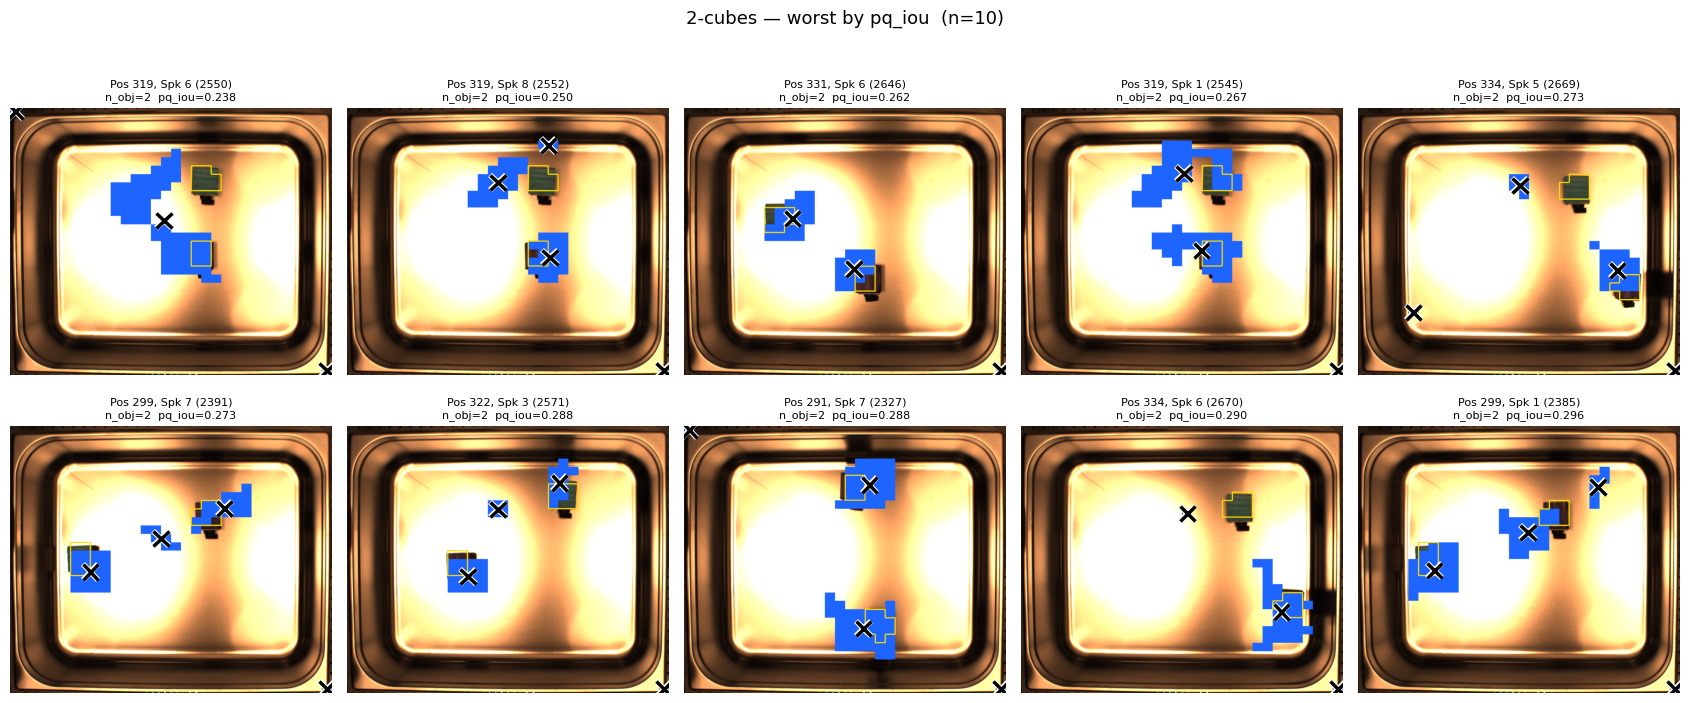

In [15]:
plot_grid(df, split="2-cubes", metric="pq_iou", order="worst", n=10)

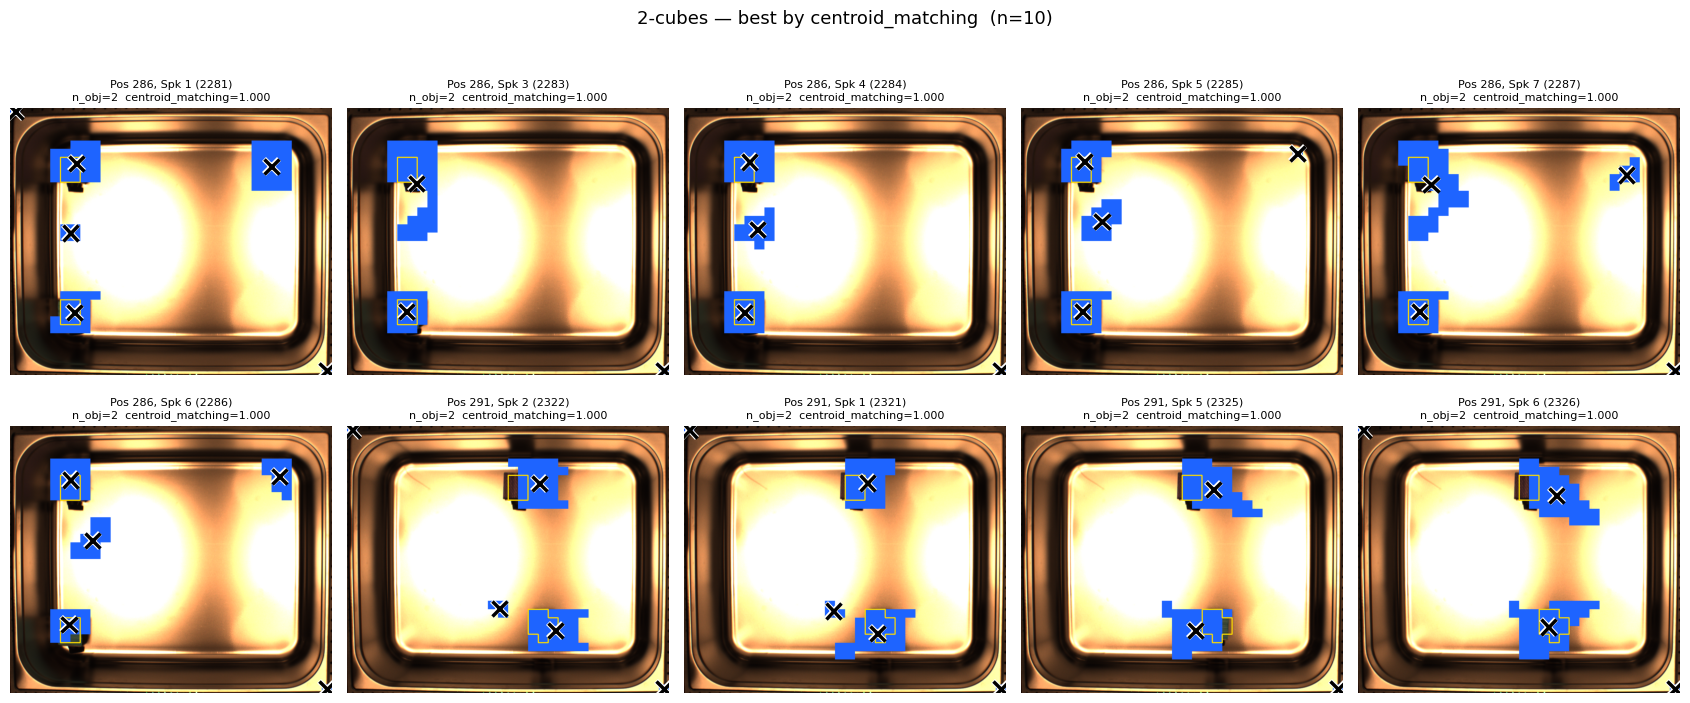

In [16]:
plot_grid(df, split="2-cubes", metric="centroid_matching", order="best", n=10)

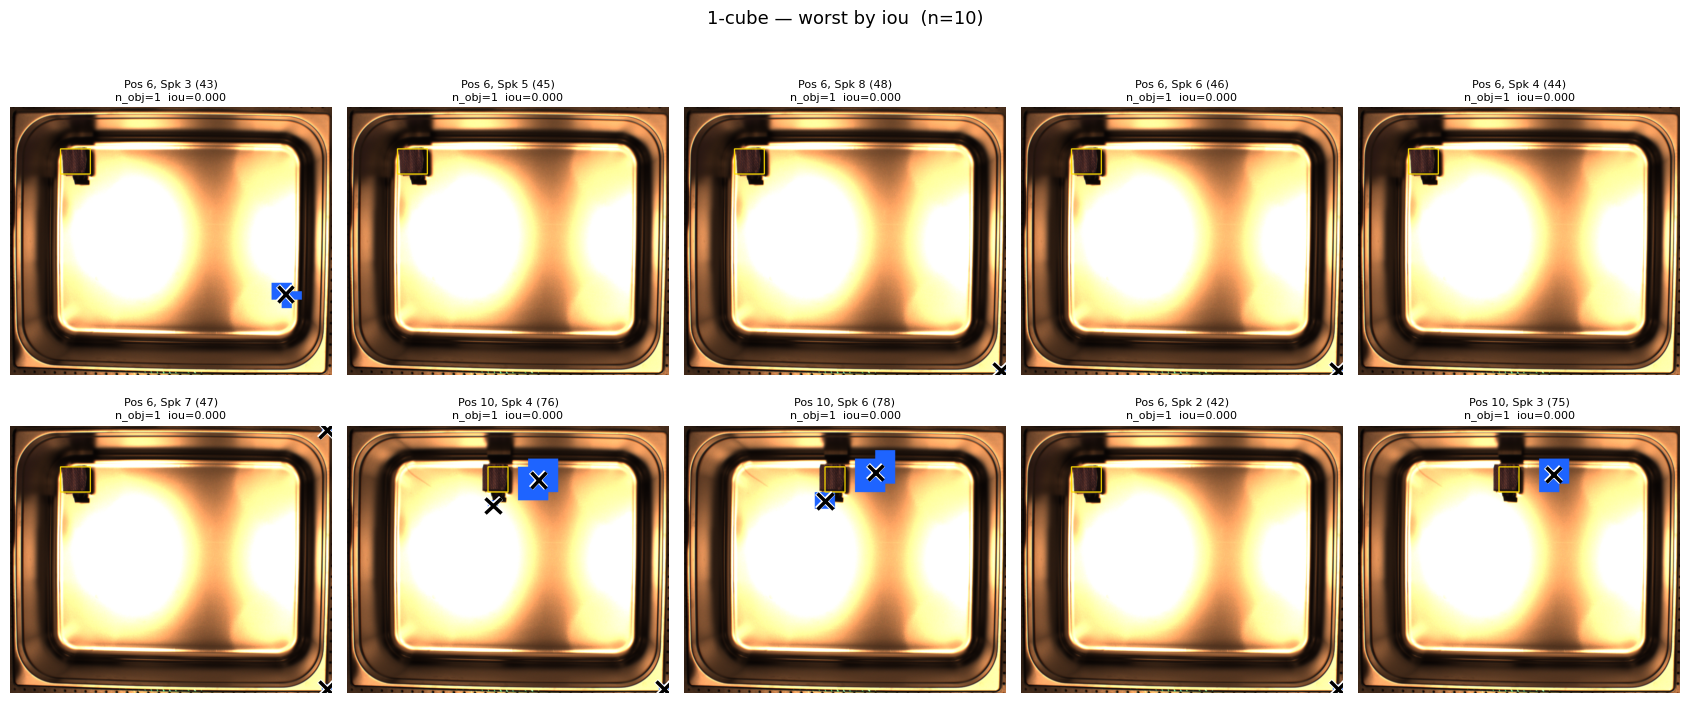

In [17]:
plot_grid(df, split="1-cube", metric="iou", order="worst", n=10)

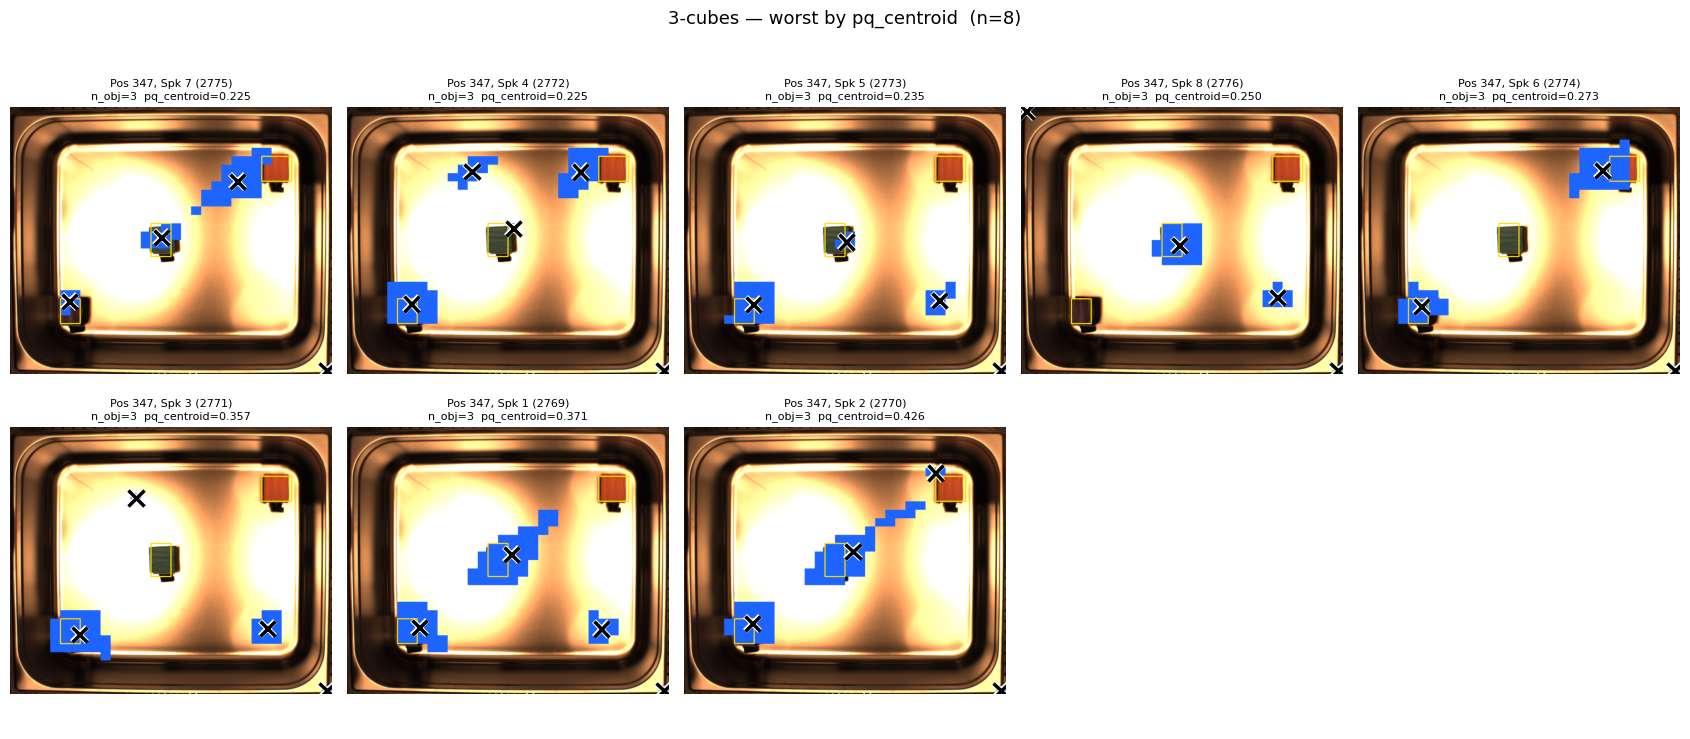

In [18]:
plot_grid(df, split="3-cubes", metric="pq_centroid", order="worst", n=10)

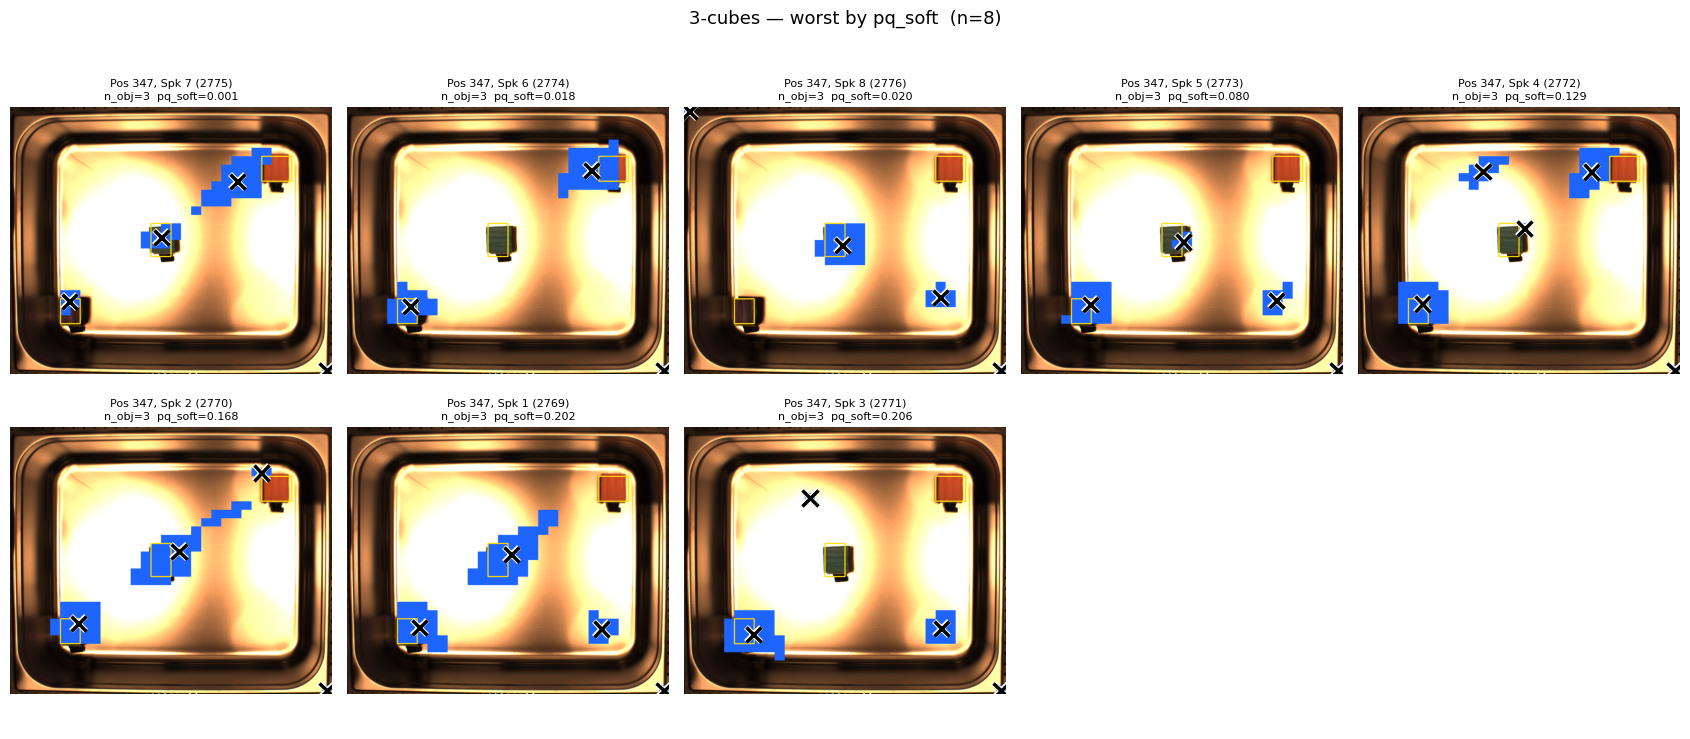

In [19]:
plot_grid(df, split="3-cubes", metric="pq_soft", order="worst", n=10)

### Playground

`split` ∈ `{"train", "1-cube", "2-cubes", "3-cubes"}`, `metric` ∈ `{"iou", "centroid_matching", "pq_iou", "sq_iou", "rq_iou", "pq_centroid", "sq_centroid", "rq_centroid", "centroid_matching_soft", "pq_soft", "sq_soft", "rq_soft"}`, `order` ∈ `{"best", "worst"}`.

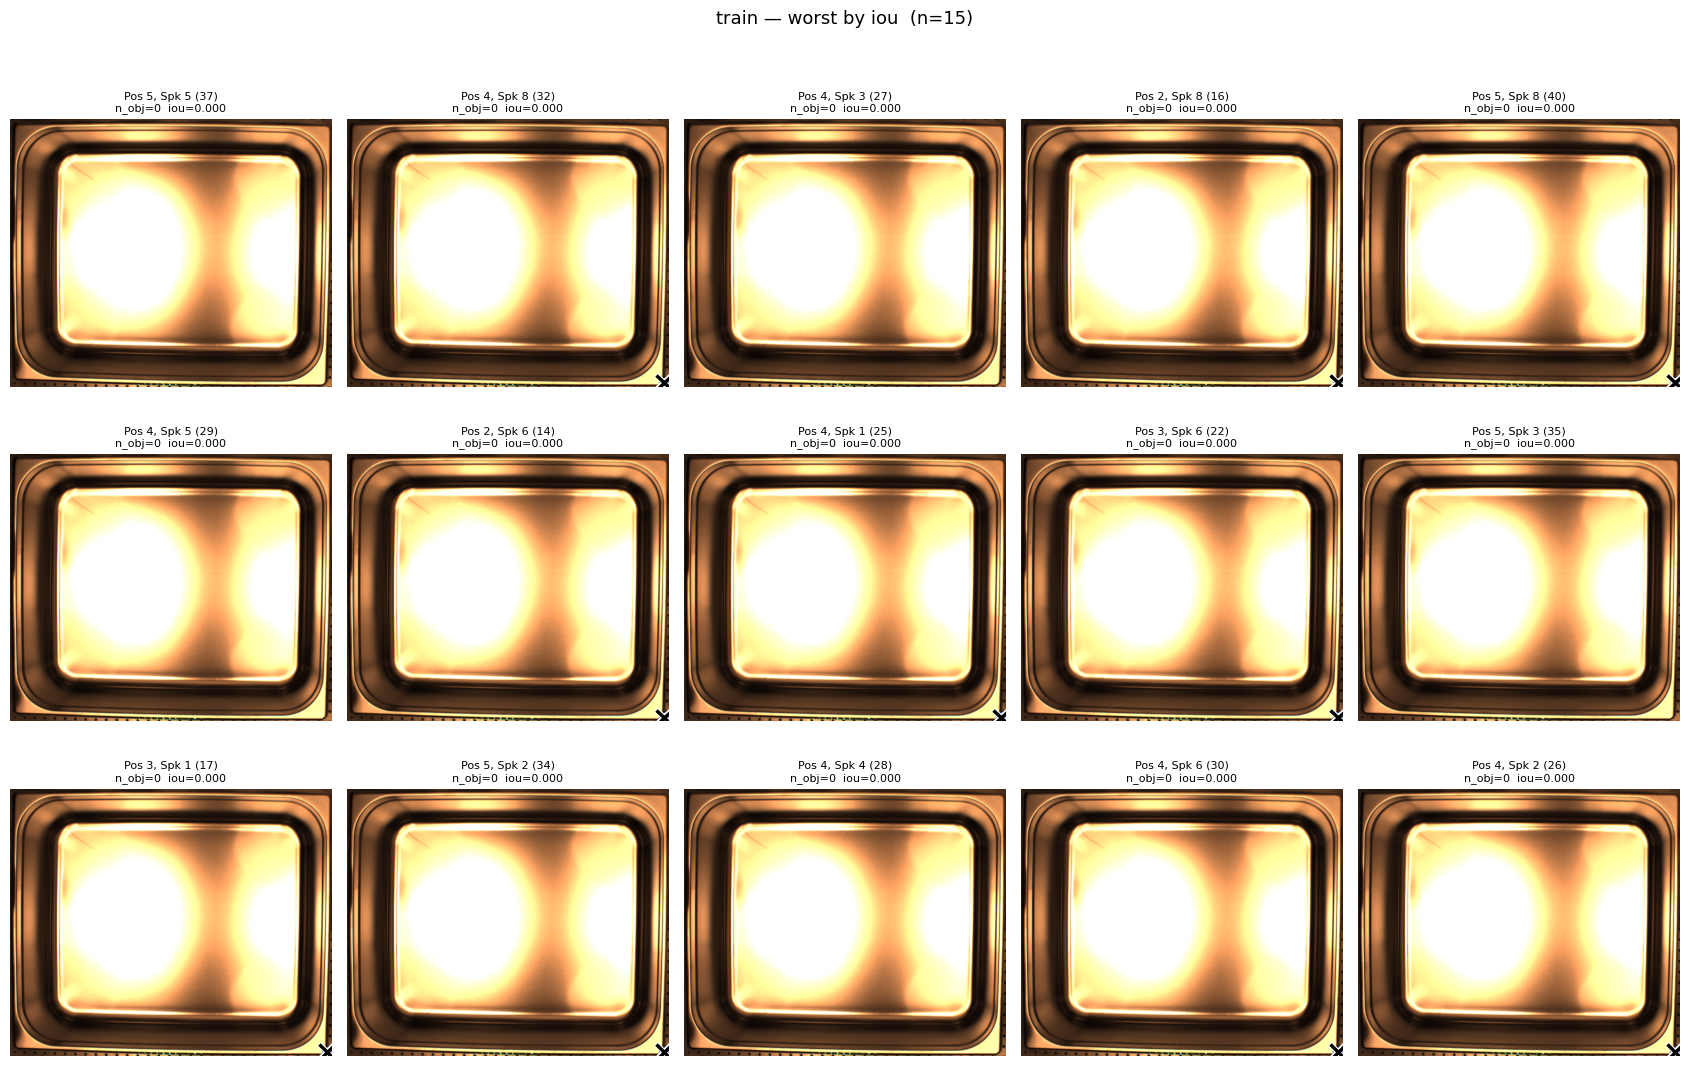

In [20]:
plot_grid(df, split="train", metric="iou", order="worst", n=15)